# Assignment 4 – Portugal | Part 2: PyPSA Model + Sensitivity Analysis

**Requires outputs from `EAnalysis.ipynb`** (run that notebook first).

In [1]:
#import of libraries
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import geopandas as gpd
import pypsa, xarray as xr
from pypsa.costs import annuity
import matplotlib.pyplot as plt

In [2]:
#assignment of important urls
url_dataset = 'https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq'
url_tech_cost = 'https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_2030.csv' #as costs the 2030 costs are chosen
url_load = f'{url_dataset}/download?path=%2Fgegis&files=load.csv'
url_pp   = f'{url_dataset}/download?path=%2Fglobal-power-plant-database&files=global_power_plant_database.csv'

In [3]:
#PyPsa import
pypsa.options.params.optimize.include_objective_constant = True

### 1. Load EAnalysis outputs

Previous results are accessed since they are useful for the following model and calculations. More specifically those are capacity factors, capacities to be installed and regions

In [4]:
#load/access region information
regions = gpd.read_file('regions.gpkg') # [EPSG:3035, m]
regions = regions.set_index('nuts2')
regions['representative_point'] = regions.geometry.representative_point() # [EPSG:3035, m]

#load/access offshore information
offshore_valid = gpd.read_file('offshore_valid.gpkg').set_index('nuts2') # [EPSG:3035, m]

#Load into memory and close file handles, so EAnalysis can re-export
#the .nc files while this kernel is still alive
def load_da(fn):
    with xr.open_dataarray(fn) as da:
        
        return da.load()

#capacity factors for all technologies
cf_wind = load_da('cf_wind.nc') # [-], onshore wind capacity factor (3h)
cf_solar = load_da('cf_solar.nc') # [-], solar pv capacity factor (3h)
cf_offshore = load_da('cf_offshore.nc') # [-], offshore wind capacity factor (3h)

#max. installed capacities per technology
p_nom_max_wind = pd.read_csv('p_nom_max_wind.csv', index_col = 0)['p_nom_max_MW'] # [MW]
p_nom_max_solar = pd.read_csv('p_nom_max_solar.csv', index_col = 0)['p_nom_max_MW'] # [MW]
p_nom_max_offshore = pd.read_csv('p_nom_max_offshore.csv', index_col = 0)['p_nom_max_MW'] # [MW]

print('Regions:', list(regions.index))
print('CF wind dim:', cf_wind.dims)
print('p_nom_max_offshore:\n', p_nom_max_offshore)

Regions: ['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte']
CF wind dim: ('time', 'nuts2')
p_nom_max_offshore:
 nuts2
Alentejo     5512.750661
Algarve     83465.168955
Centro      65569.599010
Lisboa      58028.784018
Norte       39911.710456
Name: p_nom_max_MW, dtype: float64


## 1. Technology costs (2030)

Year 2030 is chosen for projection, due to ......

In [5]:
#import of cost data repository originating from PyPSA GitHub
costs = pd.read_csv(url_tech_cost, index_col = [0, 1])

costs.loc[costs.unit.str.contains('/kW'), 'value'] *= 10**3 # [EUR/MW], unit transformation from /kW to /MW
costs.unit = costs.unit.str.replace('/kW', '/MW')
costs

value  \
technology                       parameter                         
Alkaline electrolyzer large size FOM                2.800000e+00   
                                 VOM                3.033000e-01   
                                 electricity-input  1.380000e+00   
                                 investment         5.447764e+05   
                                 lifetime           4.000000e+01   
...                                                          ...   
waste CHP CC                     efficiency-heat    7.619000e-01   
                                 investment         1.083389e+07   
                                 lifetime           2.500000e+01   
water tank charger               efficiency         9.000000e-01   
water tank discharger            efficiency         9.000000e-01   

                                                             unit  \
technology                       parameter                          
Alkaline electrolyzer large size FOM                       %/year   
                                 VOM                   EUR/MWh_H2   
                                 electricity-input  MWh_el/MWh_H2   
                                 investment                EUR/MW   
                                 lifetime                   years   
...                                                           ...   
waste CHP CC                     efficiency-heat         per unit   
                                 investment              EUR/MW_e   
                                 lifetime                   years   
water tank charger               efficiency              per unit   
water tank discharger            efficiency              per unit   

                                                                                               source  \
technology                       parameter                                                              
Alkaline electrolyzer large size FOM                JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 VOM                JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 electricity-input  JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 investment         JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 lifetime           JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
...                                                                                               ...   
waste CHP CC                     efficiency-heat    Danish Energy Agency, inputs/technology_data_f...   
                                 investment         Danish Energy Agency, inputs/technology_data_f...   
                                 lifetime           Danish Energy Agency, inputs/technology_data_f...   
water tank charger               efficiency                                                        HP   
water tank discharger            efficiency                                                        HP   

                                                                                  further description  \
technology                       parameter                                                              
Alkaline electrolyzer large size FOM                                         Reference capacity 72 MW   
                                 VOM                                         Reference capacity 72 MW   
                                 electricity-input                           Reference capacity 72 MW   
                                 investment                                  Reference capacity 72 MW   
                                 lifetime                                    Reference capacity 72 MW   
...                                                                                               ...   
waste CHP CC                     efficiency-heat    08 WtE CHP, Large,

In [6]:
#fillna values with default cost structure
defaults = {'FOM': 0, #fixed O&M as share of investment [%/a] 
            'VOM': 0, #[EUR/MWh_el]
            'efficiency': 1, #default efficienciey
            'fuel': 0, #[EUR/MWh_th]
            'investment': 0, #[EUR/MW]
            'lifetime': 25, #[a]
            'CO2 intensity': 0, #[t_CO2/MWh_th]
            'discount rate': 0.07} #[-]

costs = costs.value.unstack().fillna(defaults)

In [7]:
#defining fuel costs for OCGT and CCGT technologies
for t in ['OCGT', 'CCGT']:
    costs.at[t, 'fuel'] = costs.at['gas', 'fuel'] # [EUR/MWh_th], setting fuel costs
    costs.at[t, 'CO2 intensity'] = costs.at['gas', 'CO2 intensity']  # [t_CO2/MWh_th], setting CO2 intensity

#defining marginal costs
costs['marginal_cost'] = costs['VOM'] + costs['fuel'] / costs['efficiency'] # [EUR/MWh_el], including fuel costs and VOM costs

#defining capital cost
annuity_factor = annuity(costs['discount rate'], costs['lifetime']) # [1/a], setting annuity factor
costs['capital_cost'] = (annuity_factor + costs['FOM'] / 100) * costs['investment'] # [EUR/MW/a]

#relevant technologies with their cost character
check = ['solar', 'onwind', 'offwind', 'offwind-float', 'OCGT', 'CCGT',
         'battery storage', 'battery inverter', 'electrolysis', 'fuel cell',
         'hydrogen storage underground']

costs.loc[check, ['investment', 'lifetime', 'marginal_cost', 'capital_cost']].round(1)

parameter,investment,lifetime,marginal_cost,capital_cost
technology,,,,
solar,683146.2,40.0,0.0,64560.1
onwind,1383305.9,30.0,1.8,128306.3
offwind,2114991.0,30.0,0.0,219475.6
offwind-float,2954736.3,20.0,0.0,312885.7
OCGT,581394.9,25.0,75.3,60235.7
CCGT,1108716.6,25.0,54.6,132274.9
battery storage,189861.0,25.0,0.0,16292.1
battery inverter,213927.9,10.0,0.0,31180.5
electrolysis,1886001.9,25.0,0.0,237278.9


## 2. Load time series

In [8]:
#loading OPSD data for portugal
load_raw = pd.read_csv(url_load, index_col = 0, parse_dates = True)  # [MW], country-level load
load_pt = load_raw['PT'].loc['2013'].resample('3h').mean() # [MW], downsampling/temporal resolution to 3-hourly resolution

#load distribution via country's population as distribution key - approx. population per region was investigated
population = pd.Series({'Norte': 3689, 'Centro': 2227, 'Lisboa': 2821,
                          'Alentejo': 757, 'Algarve': 451}) # [thousand people], 2021 census

pop_share = population / population.sum() # [-], share of population
load_region = pd.DataFrame({r: load_pt * pop_share[r] for r in regions.index}) # [MW], load per region

print('Load shape:', load_region.shape)
load_region.head(2)

Load shape: (2920, 5)


,Alentejo,Algarve,Centro,Lisboa,Norte
time,,,,,
2013-01-01 00:00:00,443.115591,263.996211,1303.591044,1651.293370,2159.383638
2013-01-01 03:00:00,416.359499,248.055659,1224.877944,1551.585397,2028.996289


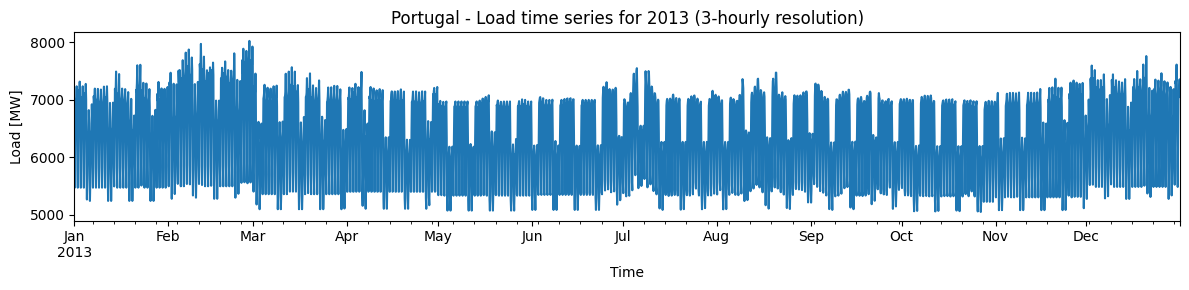

In [9]:
#plotting load series for portugal - complete
load_pt.plot(figsize = (12, 3), title = 'Portugal - Load time series for 2013 (3-hourly resolution)')
plt.ylabel('Load [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

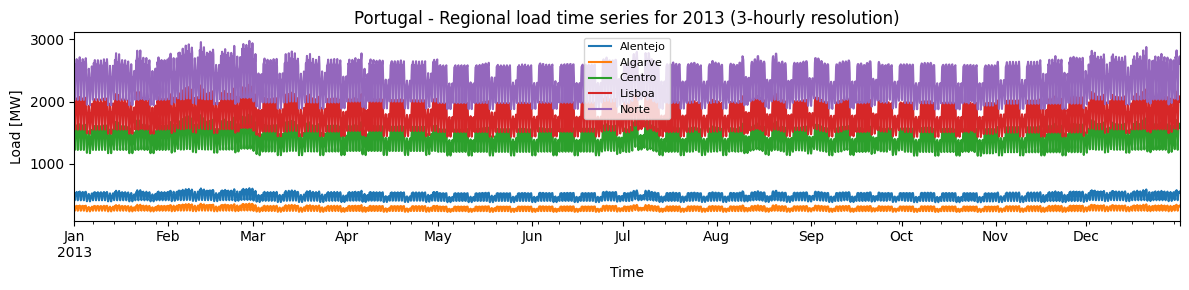

In [10]:
#plotting load series for portugal per region
load_region.plot(figsize = (12, 3), title = 'Portugal - Regional load time series for 2013 (3-hourly resolution)')
plt.ylabel('Load [MW]')
plt.xlabel('Time')
plt.legend(fontsize = 8)
plt.tight_layout()
plt.show()

## 3. Existing power plants

In [11]:
#loading global power plant database
pp_raw = pd.read_csv(url_pp, low_memory = False) #raw database
pp_pt = pp_raw[(pp_raw['country'] == 'PRT') &
                  ~pp_raw['primary_fuel'].isin(['Wind', 'Solar'])].copy() #filtering global database for portugal - excluding wind and solar (add existing convntional pp)

pp_pt   = pp_pt.dropna(subset=['latitude', 'longitude']) #drop empty cells

pp_gdf  = gpd.GeoDataFrame(
    pp_pt, 
    geometry = gpd.points_from_xy(
        pp_pt.longitude, 
        pp_pt.latitude
        ),
           crs = 4326
           ).to_crs(3035) #coordinates -> geoemtry

pp_join = gpd.sjoin_nearest(pp_gdf, regions[['geometry']].reset_index(),
                             how = 'left', distance_col = 'dist') #assign every pp to a region that is closeby

In [12]:
#calculate hydropower capacity factor
hydro = pp_join[pp_join['primary_fuel'] == 'Hydro']
hydro_cap = hydro.groupby('nuts2')['capacity_mw'].sum() # [MW], hydropower capacities

#use estimated generation if actual 2013 column is missing/all nan values
gen_col = 'generation_gwh_2013'

if gen_col not in hydro.columns or hydro[gen_col].isna().all():
    gen_col = 'estimated_generation_gwh_2013'

hydro_gen = hydro.groupby('nuts2')[gen_col].sum() # [GWh/a], hydropower generation per year
hydro_cf = (hydro_gen * 1000 / (hydro_cap * 8760)).clip(0, 1).fillna(0.15) # [-], capacity factor (later added to the model as p_max_pu)

non_hydro = pp_join[pp_join['primary_fuel'] != 'Hydro']
conventional = non_hydro.groupby(['nuts2', 'primary_fuel'])['capacity_mw'] \
                         .sum().unstack(fill_value = 0) # [MW], capacities (later used as p_nom in the model)

print('Hydro CF:\n', hydro_cf.round(3))
print('Conventional [MW]:\n', conventional)

Hydro CF:
 nuts2
Alentejo    0.366
Algarve     0.332
Centro      0.322
Lisboa      0.342
Norte       0.311
dtype: float64
Conventional [MW]:
 primary_fuel  Biomass    Coal     Gas  Geothermal  Waste
nuts2                                                   
Algarve           0.0     0.0     0.0         0.0   10.9
Centro          347.7   682.0  1663.0        28.8   18.5
Lisboa           66.4  1296.0  1176.0         0.0   62.2
Norte            38.8     0.0   990.0         0.0   40.2


### Visualization of PyPSA Network

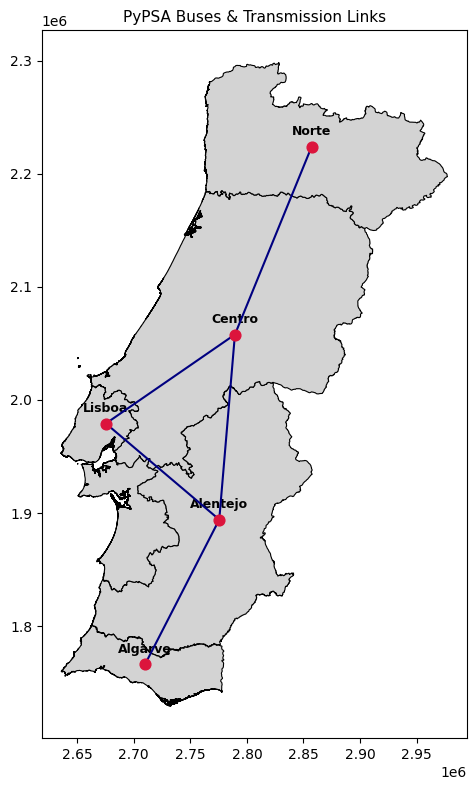

In [13]:
#buses and transmission lines of the network
#defining neighbouring regions
lines = [('Norte','Centro'), ('Centro','Lisboa'), ('Centro','Alentejo'),
         ('Lisboa','Alentejo'), ('Alentejo','Algarve')]

#plot
fig, ax = plt.subplots(figsize = (6, 8))
regions.plot(ax = ax, color = 'lightgrey', edgecolor = 'k', linewidth = 0.8)

#per region there is one representative point illustrated as a red point
for region, row in regions.iterrows():
    pt = row['representative_point']
    ax.scatter(pt.x, pt.y, color = 'crimson', s = 60, zorder = 5)
    ax.annotate(region, (pt.x, pt.y), xytext = (0, 8), textcoords = 'offset points',
                ha = 'center', fontsize = 9, fontweight = 'bold')

#draw lines between the representative points
for r1, r2 in lines:
    p1, p2 = regions.at[r1, 'representative_point'], regions.at[r2, 'representative_point']
    ax.plot([p1.x, p2.x], [p1.y, p2.y], color = 'navy', linewidth = 1.5, zorder = 4)

ax.set_title('PyPSA Buses & Transmission Links', fontsize = 11)
plt.tight_layout()
plt.show()

## 4. `build_network()` function

In [14]:
#model with category 2. variations of technology costs (solar) for sensitivity analysis
def build_network(solar_cost_factor):
    n = pypsa.Network()
    n.set_snapshots(load_region.index) # [3h], temporal resolution - 2920 snapshots
    n.snapshot_weightings.loc[:, :] = 3.0   # [h] each snapshot represents 3 hours

    #buses representing the regions
    for region, row in regions.iterrows():
        pt = row['representative_point'] # [m], EPSG:3035
        n.add('Bus', region, x = pt.x, y = pt.y, carrier = 'AC')

    #loads per region
    for region in regions.index:
        n.add('Load', f'load-{region}', bus = region, p_set = load_region[region])  # [MW]

    #Hydropower modeled as Generator with constant capacitiy factor
    for region in regions.index:
        cap = float(hydro_cap.get(region, 0)) # [MW]
        if cap > 0:
            n.add('Generator', f'hydro-{region}', bus = region, carrier = 'hydro',
                  p_nom = cap, p_nom_extendable = False,                 # [MW]
                  p_max_pu = float(hydro_cf.get(region, 0.15)),          # [-]
                  marginal_cost = 0., capital_cost = 0.)                 # [EUR/MWh], [EUR/MW/a]

    #adding emissions information per technology/carrier
    n.add('Carrier', 'gas', co2_emissions = costs.at['gas',  'CO2 intensity'])  # [t_CO2/MWh_th]
    n.add('Carrier', 'coal', co2_emissions = costs.at['coal', 'CO2 intensity']) # [t_CO2/MWh_th]
    n.add('Carrier', 'biomass', co2_emissions = 0.) # [t_CO2/MWh_th], simplified assumption
    n.add('Carrier', 'waste', co2_emissions = 0.) # [t_CO2/MWh_th], simplified assumption

    #adding carriers for renewable technologies
    n.add('Carrier', 'hydro')
    n.add('Carrier', 'onwind')
    n.add('Carrier', 'solar')
    n.add('Carrier', 'offwind')
    n.add('Carrier', 'battery')
    n.add('Carrier', 'H2')

    #adding existing conventional power plants to network - aggregated to one representative generator per technology and region
    biomass_mc = costs.at['biomass', 'marginal_cost'] if 'biomass' in costs.index else 3.0 # [EUR/MWh_el]
    fuel_map = {
        'Gas': ('gas', costs.at['CCGT', 'marginal_cost']),   # [EUR/MWh_el]
        'Coal': ('coal', costs.at['coal', 'marginal_cost']), # [EUR/MWh_el]
        'Biomass': ('biomass', biomass_mc),                  # [EUR/MWh_el]
        'Waste': ('waste', biomass_mc),                      # [EUR/MWh_el]
    }
    for fuel, (carrier, mc) in fuel_map.items():
        if fuel not in conventional.columns: continue
        for region in regions.index:
            if region not in conventional.index: continue
            cap = float(conventional.at[region, fuel]) # [MW]
            if cap > 0:
                n.add('Generator', f'{fuel.lower()}-{region}', bus = region,
                      carrier = carrier, p_nom = cap, p_nom_extendable = False,  # [MW]
                      marginal_cost = mc, capital_cost = 0.)                     # [EUR/MWh], [EUR/MW/a]

    #solar and on-/offshore wind geenerator per region
    solar_cc = costs.at['solar', 'capital_cost'] * solar_cost_factor # [EUR/MW/a]

    for region in regions.index:
        #generator for onshore wind
        n.add('Generator', f'onwind-{region}', bus = region, carrier = 'onwind',
              p_nom_extendable = True,
              p_nom_max = float(p_nom_max_wind.get(region, 0)),        # [MW]
              p_max_pu = cf_wind.sel(nuts2 = region).values,           # [-]
              capital_cost = costs.at['onwind', 'capital_cost'],       # [EUR/MW/a]
              marginal_cost = costs.at['onwind', 'marginal_cost'])     # [EUR/MWh]
        
        #generator for solar pv
        n.add('Generator', f'solar-{region}', bus = region, carrier = 'solar',
              p_nom_extendable = True,
              p_nom_max = float(p_nom_max_solar.get(region, 0)),       # [MW]
              p_max_pu = cf_solar.sel(nuts2 = region).values,          # [-]
              capital_cost = solar_cc,                                 # [EUR/MW/a]
              marginal_cost = costs.at['solar', 'marginal_cost'])      # [EUR/MWh]
        
        if float(p_nom_max_offshore.get(region, 0)) > 0:
            #generator for offshore wind
            n.add('Generator', f'offwind-{region}', bus = region, carrier = 'offwind',
                  p_nom_extendable = True,
                  p_nom_max = float(p_nom_max_offshore.get(region, 0)),      # [MW]
                  p_max_pu = cf_offshore.sel(nuts2 = region).values,         # [-]
                  capital_cost = costs.at['offwind-float', 'capital_cost'],  # [EUR/MW/a]
                  marginal_cost = costs.at['offwind-float', 'marginal_cost'])# [EUR/MWh]
            
        #generator for gas
        n.add('Generator', f'OCGT-{region}', bus = region, carrier = 'gas',
              p_nom_extendable = True,
              capital_cost = costs.at['OCGT', 'capital_cost'],         # [EUR/MW/a]
              marginal_cost = costs.at['OCGT', 'marginal_cost'])       # [EUR/MWh]

    #transmission links (700 EUR/MW/km x 1.5 detour factor x crow-fly distance)
    for r1, r2 in [('Norte','Centro'), ('Centro','Lisboa'), ('Centro','Alentejo'),
                   ('Lisboa','Alentejo'), ('Alentejo','Algarve')]:
        pt1 = regions.at[r1, 'representative_point']
        pt2 = regions.at[r2, 'representative_point']
        dist_km = pt1.distance(pt2) / 1000 * 1.5 # [km], incl. detour factor

        n.add('Link', f'line-{r1}-{r2}', bus0 = r1, bus1 = r2, p_min_pu = -1,
              p_nom_extendable = True, capital_cost = 700 * dist_km, marginal_cost = 0.) # [EUR/MW/a]

    #battery storage options (2h/4h/6h)
    batt_cc = costs.at['battery inverter', 'capital_cost'] # [EUR/MW/a]
    batt_e_cc = costs.at['battery storage',  'capital_cost'] # [EUR/MWh/a]

    for region in regions.index:
        for hours_bat in [2, 4, 6]: # [h], energy/power ratio
            n.add('StorageUnit', f'battery-{hours_bat}h-{region}', bus = region, carrier = 'battery',
                  p_nom_extendable = True, max_hours = hours_bat,
                  capital_cost = batt_cc + hours_bat * batt_e_cc,      # [EUR/MW/a]
                  efficiency_store = costs.at['battery inverter', 'efficiency'],     # [-]
                  efficiency_dispatch = costs.at['battery inverter', 'efficiency'],  # [-]
                  cyclic_state_of_charge = True)

    #hydrogen storage options (168h/336h/672h)
    h2_power_cc = costs.at['electrolysis', 'capital_cost'] + costs.at['fuel cell', 'capital_cost'] # [EUR/MW/a]
    h2_energy_cc = costs.at['hydrogen storage underground', 'capital_cost'] # [EUR/MWh/a]

    for region in regions.index:
        for hours_h2 in [168, 336, 672]: # [h], energy/power ratio
            n.add('StorageUnit', f'H2-{hours_h2}h-{region}', bus = region, carrier = 'H2',
                  p_nom_extendable = True, max_hours = hours_h2,
                  capital_cost = h2_power_cc + hours_h2 * h2_energy_cc,   # [EUR/MW/a]
                  efficiency_store = costs.at['electrolysis', 'efficiency'],   # [-]
                  efficiency_dispatch = costs.at['fuel cell', 'efficiency'],   # [-]
                  cyclic_state_of_charge = True)
            
    return n

print('build_network() defined.')
print(f'Solar base capital cost: {costs.at["solar", "capital_cost"]:.0f} EUR/MW/a')

build_network() defined.
Solar base capital cost: 64560 EUR/MW/a


### 5. Investigation

#### 5.1 Without CO₂ emissions limit

In [15]:
#model run without any CO2 emissions
n_free = build_network(solar_cost_factor = 1.0)
n_free.optimize(solver_name = 'gurobi')

print('=== No CO2 limit ===')
print(f'Total cost: {n_free.objective/1e9:.2f} bn EUR/yr')
print(n_free.generators.groupby('carrier')['p_nom_opt'].sum().round(0))
n_free.export_to_netcdf('network_free.nc')
print('Saved: network_free.nc')

Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 130.31it/s]
INFO:linopy.io: Writing time: 0.84s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


INFO:gurobipy:Set parameter WLSSecret


...

INFO:gurobipy:Optimal objective  2.079811206e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873150 duals
Objective: 2.08e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


=== No CO2 limit ===
Total cost: 2.08 bn EUR/yr
carrier
biomass     453.0
coal       1978.0
gas        4958.0
hydro      2760.0
offwind      70.0
onwind       21.0
solar      6344.0
waste       132.0
Name: p_nom_opt, dtype: float64


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'network_free.nc contains: carriers, sub_networks, links, loads, buses, generators, storage_units


Saved: network_free.nc


#### 5.2 Zero CO₂

In [16]:
#model run with 0 CO2 emissions
n_zero = build_network(solar_cost_factor = 1.0)
n_zero.add('GlobalConstraint', 'co2_limit', sense ='<=', constant = 0.,
           carrier_attribute = 'co2_emissions')
n_zero.optimize(solver_name = 'gurobi')

print('=== Zero CO2 ===')
print(f'Total cost: {n_zero.objective/1e9:.2f} bn EUR/yr')
print(n_zero.generators.groupby('carrier')['p_nom_opt'].sum().round(0))
n_zero.export_to_netcdf('network_zero.nc')
print('Saved: network_zero.nc')

Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 44.35it/s]
INFO:linopy.io: Writing time: 1.01s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


INFO:gurobipy:Set parameter WLSSecret


...

INFO:gurobipy:Optimal objective  5.616021358e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873151 duals
Objective: 5.62e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


=== Zero CO2 ===
Total cost: 5.62 bn EUR/yr
carrier
biomass      453.0
coal        1978.0
gas         3829.0
hydro       2760.0
offwind     3306.0
onwind      2074.0
solar      26113.0
waste        132.0
Name: p_nom_opt, dtype: float64


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'network_zero.nc contains: carriers, sub_networks, links, loads, buses, generators, global_constraints, storage_units


Saved: network_zero.nc


#### Summary of scenarios

In [17]:
#total actual production grouped by carrier
gen_free = n_free.generators_t.p.groupby(n_free.generators.carrier, axis=1).sum().mean()  # [MW]
gen_zero = n_zero.generators_t.p.groupby(n_zero.generators.carrier, axis=1).sum().mean()  # [MW]

print(pd.DataFrame({'No CO2 [MW]': gen_free, 'Net Zero [MW]': gen_zero}).fillna(0).round(1))

         No CO2 [MW]  Net Zero [MW]
carrier                            
biomass        450.1          141.1
coal          1865.8            0.0
gas           1810.1            0.0
hydro          871.9          871.9
offwind         38.8         1759.5
onwind           3.8          217.6
solar         1212.9         4011.0
waste          128.5           41.8


=== Capacity comparison ===
         No CO2 limit [GW]  Net Zero [GW]
carrier                                  
biomass               0.45           0.45
coal                  1.98           1.98
gas                   4.96           3.83
hydro                 2.76           2.76
offwind               0.07           3.31
onwind                0.02           2.07
solar                 6.34          26.11
waste                 0.13           0.13

Cost Run 1: 2.08 bn EUR/yr
Cost Run 2: 5.62 bn EUR/yr


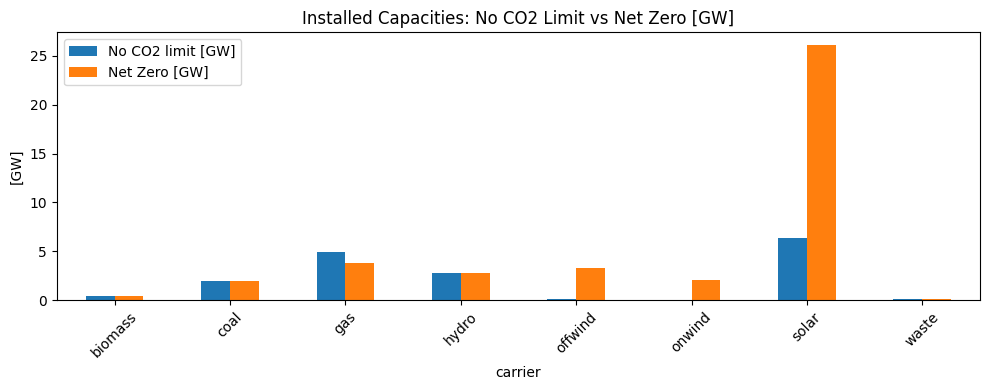

In [18]:
#comparison of the two scenarios calculated
#installed capacities
gen_free = n_free.generators.groupby('carrier')['p_nom_opt'].sum() / 10**3 # [GW]
gen_zero = n_zero.generators.groupby('carrier')['p_nom_opt'].sum() / 10**3 # [GW]

comparison = pd.DataFrame({'No CO2 limit [GW]': gen_free, 
                           'Net Zero [GW]': gen_zero}).fillna(0).round(2)

print('=== Capacity comparison ===')
print(comparison)
print(f'\nCost Run 1: {n_free.objective/1e9:.2f} bn EUR/yr')
print(f'Cost Run 2: {n_zero.objective/1e9:.2f} bn EUR/yr')

#Plot
comparison.plot(kind = 'bar', figsize = (10, 4), title = 'Installed Capacities: No CO2 Limit vs Net Zero [GW]')
plt.ylabel('[GW]')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### 5.3 Sensitivity Analysis with solar PV capital cost variation

Reduce solar cost from 100% → 75% → 50% → 25% → 0% under net-zero CO₂ constraint.

In [19]:
#Helper: solve one net-zero scenario with scaled solar cost and collect the results
def run_sensitivity(factor):
    print(f'Solving: solar cost = {factor * 100:.0f}% ...', flush = True)
    net = build_network(solar_cost_factor = factor)
    net.add('GlobalConstraint', 'co2_limit', sense ='<=', constant=0.,   # [t_CO2/a]
            carrier_attribute = 'co2_emissions')
    net.optimize(solver_name = 'gurobi')

    caps = net.generators.groupby('carrier')['p_nom_opt'].sum()    # [MW]
    stor = net.storage_units.groupby('carrier')['p_nom_opt'].sum() # [MW]
    row = {
        'solar_cost_pct':    f'{factor*100:.0f}%',
        'total_cost_bn_eur': net.objective / 10**9,          # [bn EUR/a]
        'solar_GW': caps.get('solar', 0) / 10**3,            # [GW]
        'onwind_GW': caps.get('onwind', 0) / 10**3,          # [GW]
        'offwind_GW': caps.get('offwind', 0) / 10**3,        # [GW]
        'gas_GW': caps.get('gas', 0) / 10**3,                # [GW] existing gas + new OCGT
        'battery_GW': stor.get('battery', 0) / 10**3,        # [GW]
        'H2_GW': stor.get('H2', 0) / 10**3,                  # [GW]
        'transmission_GW': net.links['p_nom_opt'].sum() / 10**3,  # [GW]
    }
    print(f'  Cost: {row["total_cost_bn_eur"]:.2f} bn EUR/yr | Solar: {row["solar_GW"]:.1f} GW')
    return row

results = []
print('Helper defined')

Helper defined


#### 5.3.1 Solar cost 100%

In [20]:
#scenario 1/5: solar cost 100%
results.append(run_sensitivity(1.0))

Solving: solar cost = 100% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 91.38it/s]
INFO:linopy.io: Writing time: 0.82s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


...

INFO:gurobipy:Solved in 275799 iterations and 127.09 seconds (51.61 work units)


Optimal objective  5.616021358e+09


INFO:gurobipy:Optimal objective  5.616021358e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873151 duals
Objective: 5.62e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


  Cost: 5.62 bn EUR/yr | Solar: 26.1 GW


#### 5.3.2 Solar cost 75%

In [21]:
#scenario 2/5: solar cost 75%
results.append(run_sensitivity(0.75))

Solving: solar cost = 75% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 109.47it/s]
INFO:linopy.io: Writing time: 0.78s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


...

INFO:gurobipy:Solved in 157048 iterations and 90.45 seconds (32.11 work units)


Optimal objective  5.155604528e+09


INFO:gurobipy:Optimal objective  5.155604528e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873151 duals
Objective: 5.16e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


  Cost: 5.16 bn EUR/yr | Solar: 30.5 GW


#### 5.3.3 Solar cost 50%

In [22]:
#scenario 3/5: solar cost 50%
results.append(run_sensitivity(0.50))

Solving: solar cost = 50% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 102.22it/s]
INFO:linopy.io: Writing time: 0.97s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


...

INFO:gurobipy:Solved in 154527 iterations and 105.55 seconds (38.72 work units)


Optimal objective  4.605446743e+09


INFO:gurobipy:Optimal objective  4.605446743e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873151 duals
Objective: 4.61e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


  Cost: 4.61 bn EUR/yr | Solar: 37.9 GW


#### 5.3.4 Solar cost 25%

In [23]:
#scenario 4/5: solar cost 25%
results.append(run_sensitivity(0.25))

Solving: solar cost = 25% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 89.29it/s]
INFO:linopy.io: Writing time: 0.91s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


...

INFO:gurobipy:Solved in 123562 iterations and 82.22 seconds (29.37 work units)


Optimal objective  3.926765080e+09


INFO:gurobipy:Optimal objective  3.926765080e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873151 duals
Objective: 3.93e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


  Cost: 3.93 bn EUR/yr | Solar: 48.3 GW


#### 5.3.5 Solar cost 0%

In [24]:
#scenario 5/5: solar cost 0%
results.append(run_sensitivity(0.0))

Solving: solar cost = 0% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 83.01it/s]
INFO:linopy.io: Writing time: 0.91s


Set parameter WLSAccessID


INFO:gurobipy:Set parameter WLSAccessID


Set parameter WLSSecret


...

INFO:gurobipy:Solved in 172747 iterations and 87.21 seconds (29.52 work units)


Optimal objective  2.819549414e+09


INFO:gurobipy:Optimal objective  2.819549414e+09


INFO:gurobipy:Warning: environment still referenced so free is deferred (Continue to use WLS)
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 385495 primals, 873151 duals
Objective: 2.82e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


  Cost: 2.82 bn EUR/yr | Solar: 87.6 GW


#### 5.3.6 Summary of sensitivity analysis

In [25]:
#Collect all scenario results and save
df_sens = pd.DataFrame(results).drop_duplicates('solar_cost_pct', keep = 'last') \
                                .set_index('solar_cost_pct')
df_sens.to_csv('sensitivity_results.csv')

print('Saved: sensitivity_results.csv')
df_sens.round(2)

Saved: sensitivity_results.csv


,total_cost_bn_eur,solar_GW,onwind_GW,offwind_GW,gas_GW,battery_GW,H2_GW,transmission_GW
solar_cost_pct,,,,,,,,
100%,5.62,26.11,2.07,3.31,3.83,9.05,2.04,0.85
75%,5.16,30.49,1.95,2.53,3.83,10.06,1.77,1.09
50%,4.61,37.89,1.89,1.89,3.83,10.41,1.53,1.26
25%,3.93,48.26,1.93,1.79,3.83,10.64,1.25,1.31
0%,2.82,87.63,2.06,1.46,3.83,10.89,0.89,1.25
